In [8]:
!pip install rank_bm25 sentence-transformers faiss-cpu -q

In [9]:
import pandas as pd
import numpy as np
import pickle, os, re, time
from math import log2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords', quiet=True)

STOP = set(stopwords.words('english'))
PS   = PorterStemmer()

# ── Load data ────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/b22dckh131hongkhnhvn/arxiv-preprocessed/arxiv_preprocessed.csv'
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['text_tfidf','text_semantic','text_recommend'])
df = df.reset_index(drop=True)

print(f"✅ Dataset: {len(df):,} papers")
print(f"   Year range: {df['year'].min()} – {df['year'].max()}")
print(f"   Categories:\n{df['categories'].str.split().explode().value_counts().head(6)}")

✅ Dataset: 100,000 papers
   Year range: 2018 – 2026
   Categories:
categories
cs.LG      55929
cs.CV      36138
stat.ML    32922
cs.AI      16708
cs.CL      16301
eess.IV     6432
Name: count, dtype: int64


In [14]:
# ── Paths ────────────────────────────────────────────────────
TV1_DIR = '/kaggle/input/datasets/b22dckh131hongkhnhvn/tv1-models'
TV2_DIR = '/kaggle/input/datasets/b22dckh131hongkhnhvn/models-tv2'
TV3_DIR = '/kaggle/input/datasets/b22dckh131hongkhnhvn/models-tv3'

# ── TV1: TF-IDF + BM25 ───────────────────────────────────────
print("Loading TV1 models...")
tfidf_vec      = pickle.load(open(f'{TV1_DIR}/tfidf_vectorizer.pkl','rb'))
tfidf_mat      = pickle.load(open(f'{TV1_DIR}/tfidf_matrix.pkl','rb'))
corpus_tokens  = pickle.load(open(f'{TV1_DIR}/corpus_tokens.pkl','rb'))
bm25           = pickle.load(open(f'{TV1_DIR}/bm25.pkl','rb'))
print(f"  TF-IDF matrix: {tfidf_mat.shape}")
print(f"  BM25 corpus:   {len(corpus_tokens):,} docs")

# ── TV2: Semantic SPECTER + FAISS ────────────────────────────
print("\nLoading TV2 models...")
sbert      = SentenceTransformer('allenai-specter')
embeddings = np.load(f'{TV2_DIR}/embeddings.npy').astype('float32')
faiss_idx  = faiss.read_index(f'{TV2_DIR}/faiss_flat.index')
print(f"  Embeddings shape: {embeddings.shape}")
print(f"  FAISS index:      {faiss_idx.ntotal:,} vectors")

# ── TV3: D2D TF-IDF + BM25 + Cosine ─────────────────────────
print("\nLoading TV3 models...")
tv3_tfidf_vec = pickle.load(open(f'{TV3_DIR}/tv3_tfidf_vec.pkl','rb'))
tv3_tfidf_mat = pickle.load(open(f'{TV3_DIR}/tv3_tfidf_mat.pkl','rb'))
tv3_count_vec = pickle.load(open(f'{TV3_DIR}/tv3_count_vec.pkl','rb'))
tv3_count_mat = pickle.load(open(f'{TV3_DIR}/tv3_count_mat.pkl','rb'))
tv3_bm25      = pickle.load(open(f'{TV3_DIR}/tv3_bm25.pkl','rb'))
tv3_tokens    = [str(t).split() for t in df['text_recommend']]
print(f"  TV3 TF-IDF matrix: {tv3_tfidf_mat.shape}")

print("\n✅ Tất cả models loaded!")

Loading TV1 models...
  TF-IDF matrix: (100000, 100000)
  BM25 corpus:   100,000 docs

Loading TV2 models...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/allenai-specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embeddings shape: (100000, 768)
  FAISS index:      100,000 vectors

Loading TV3 models...
  TV3 TF-IDF matrix: (100000, 40000)

✅ Tất cả models loaded!


In [15]:
def _preprocess(text: str) -> str:
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    return ' '.join([PS.stem(t) for t in text.split()
                     if t not in STOP and len(t) > 2])

def _category_set(value) -> set:
    return set(str(value).split())

# ── TV1: TF-IDF ──────────────────────────────────────────────
def retrieve_tfidf(query: str, top_k: int = 20) -> list:
    q_vec  = tfidf_vec.transform([_preprocess(query)])
    scores = cosine_similarity(q_vec, tfidf_mat).flatten()
    idx    = scores.argsort()[::-1][:top_k]
    return idx.tolist()

# ── TV1: BM25 ────────────────────────────────────────────────
def retrieve_bm25(query: str, top_k: int = 20) -> list:
    tokens = _preprocess(query).split()
    scores = np.array(bm25.get_scores(tokens))
    idx    = scores.argsort()[::-1][:top_k]
    return idx.tolist()

# ── TV2: Semantic SPECTER ─────────────────────────────────────
def retrieve_semantic(query: str, top_k: int = 20) -> list:
    q_emb = sbert.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True
    ).astype('float32')
    _, indices = faiss_idx.search(q_emb, top_k)
    return indices[0].tolist()

# ── TV3: D2D TF-IDF ──────────────────────────────────────────
def retrieve_d2d_tfidf(query: str, top_k: int = 20) -> list:
    # Tìm paper gần query nhất làm seed
    q_vec    = tv3_tfidf_vec.transform([query])
    seed_sc  = cosine_similarity(q_vec, tv3_tfidf_mat).flatten()
    seed_idx = int(seed_sc.argsort()[-1])
    # D2D từ seed
    doc_sc   = linear_kernel(tv3_tfidf_mat[seed_idx], tv3_tfidf_mat).flatten()
    doc_sc[seed_idx] = 0
    return doc_sc.argsort()[::-1][:top_k].tolist()

# ── TV3: D2D BM25 ────────────────────────────────────────────
def retrieve_d2d_bm25(query: str, top_k: int = 20) -> list:
    q_vec    = tv3_tfidf_vec.transform([query])
    seed_sc  = cosine_similarity(q_vec, tv3_tfidf_mat).flatten()
    seed_idx = int(seed_sc.argsort()[-1])
    scores   = np.array(tv3_bm25.get_scores(tv3_tokens[seed_idx]))
    scores[seed_idx] = 0
    return scores.argsort()[::-1][:top_k].tolist()

# ── Random baseline ───────────────────────────────────────────
def retrieve_random(query: str, top_k: int = 20) -> list:
    return np.random.choice(len(df), top_k, replace=False).tolist()

# ── Dict tất cả methods ───────────────────────────────────────
ALL_METHODS = {
    'TF-IDF':    retrieve_tfidf,
    'BM25':      retrieve_bm25,
    'Semantic':  retrieve_semantic,
    'D2D-TFIDF': retrieve_d2d_tfidf,
    'D2D-BM25':  retrieve_d2d_bm25,
    'Random':    retrieve_random,
}

print("✅ Tất cả retrieve functions ready!")

✅ Tất cả retrieve functions ready!


In [16]:
def precision_at_k(ranked: list, query_cats: set, k: int) -> float:
    hits = sum(
        1 for i in ranked[:k]
        if len(query_cats & _category_set(df.loc[i,'categories'])) > 0
    )
    return hits / k

def recall_at_k(ranked: list, query_cats: set,
                k: int, total_rel: int) -> float:
    hits = sum(
        1 for i in ranked[:k]
        if len(query_cats & _category_set(df.loc[i,'categories'])) > 0
    )
    return hits / total_rel if total_rel > 0 else 0.0

def ndcg_at_k(ranked: list, query_cats: set, k: int) -> float:
    rels = [
        1 if len(query_cats & _category_set(df.loc[i,'categories'])) > 0
        else 0
        for i in ranked[:k]
    ]
    dcg  = sum(r / log2(rank+2) for rank, r in enumerate(rels))
    idcg = sum(1 / log2(rank+2) for rank in range(min(sum(rels), k)))
    return dcg / idcg if idcg > 0 else 0.0

def f1_at_k(p: float, r: float) -> float:
    return 2*p*r/(p+r) if (p+r) > 0 else 0.0

print("✅ Metrics functions ready!")

✅ Metrics functions ready!


In [17]:
# ════════════════════════════════════════════════════════════
# BỘ QUERY TEST CHUNG — dùng cho cả 3 thành viên
# Mỗi query đại diện cho 1 chủ đề trong dataset
# ════════════════════════════════════════════════════════════
TEST_QUERIES = [
    # IR / Search
    "dense retrieval passage ranking",
    "neural information retrieval document ranking",
    # NLP / Language Models
    "transformer attention natural language processing",
    "large language model instruction tuning RLHF",
    "text classification sentiment analysis",
    # Machine Learning
    "graph neural network node classification",
    "contrastive learning self supervised representation",
    "few shot learning meta learning generalization",
    # Computer Vision
    "image classification convolutional neural network",
    "generative model image synthesis diffusion",
    # Reinforcement Learning
    "reinforcement learning reward optimization policy",
]

print(f"Tổng số test queries: {len(TEST_QUERIES)}")
for i, q in enumerate(TEST_QUERIES, 1):
    print(f"  {i:>2}. {q}")

Tổng số test queries: 11
   1. dense retrieval passage ranking
   2. neural information retrieval document ranking
   3. transformer attention natural language processing
   4. large language model instruction tuning RLHF
   5. text classification sentiment analysis
   6. graph neural network node classification
   7. contrastive learning self supervised representation
   8. few shot learning meta learning generalization
   9. image classification convolutional neural network
  10. generative model image synthesis diffusion
  11. reinforcement learning reward optimization policy


In [18]:
def run_evaluation(queries: list,
                   methods: dict,
                   k_values: list = [5, 10, 20],
                   top_k_retrieve: int = 25) -> pd.DataFrame:
    """
    Chạy evaluation cho tất cả methods × tất cả queries
    Ground truth: category overlap (pseudo relevance)
    """
    records = []
    np.random.seed(42)

    # Pre-compute category sets để tăng tốc
    cat_sets = [_category_set(df.loc[i,'categories']) for i in range(len(df))]

    for query in tqdm(queries, desc="Queries"):
        # Tìm paper đại diện cho query → lấy category làm ground truth
        q_proc   = _preprocess(query)
        q_vec    = tfidf_vec.transform([q_proc])
        seed_sc  = cosine_similarity(q_vec, tfidf_mat).flatten()
        seed_idx = int(seed_sc.argsort()[-1])
        query_cats = cat_sets[seed_idx]

        # Tổng relevant trong corpus
        total_rel = sum(
            1 for i in range(len(df))
            if i != seed_idx and
            len(query_cats & cat_sets[i]) > 0
        )

        for method_name, fn in methods.items():
            t0 = time.time()
            try:
                ranked = fn(query, top_k=top_k_retrieve)
                # Loại seed paper khỏi ranked list
                ranked = [i for i in ranked if i != seed_idx]
            except Exception as e:
                print(f"  ⚠️ {method_name} failed on '{query}': {e}")
                ranked = []
            latency = (time.time() - t0) * 1000

            for k in k_values:
                p  = precision_at_k(ranked, query_cats, k)
                r  = recall_at_k(ranked, query_cats, k, total_rel)
                n  = ndcg_at_k(ranked, query_cats, k)
                f1 = f1_at_k(p, r)
                records.append({
                    'query':      query[:40],
                    'method':     method_name,
                    'k':          k,
                    'P@K':        round(p, 4),
                    'R@K':        round(r, 4),
                    'NDCG@K':     round(n, 4),
                    'F1@K':       round(f1, 4),
                    'latency_ms': round(latency, 1),
                })

    return pd.DataFrame(records)

eval_df = run_evaluation(TEST_QUERIES, ALL_METHODS, k_values=[5, 10, 20])
eval_df.to_csv('/kaggle/working/evaluation_final.csv', index=False)
print(f"\n✅ Saved evaluation_final.csv — {len(eval_df):,} records")

Queries:   0%|          | 0/11 [00:00<?, ?it/s]


✅ Saved evaluation_final.csv — 198 records


In [20]:
def print_summary(eval_df: pd.DataFrame, k: int = 10) -> pd.DataFrame:
    summary = eval_df.groupby(['method','k'])[
        ['P@K','R@K','NDCG@K','F1@K','latency_ms']
    ].mean().round(4)

    # Lấy K=10 để in bảng tổng kết
    s10 = summary.xs(k, level='k').sort_values('NDCG@K', ascending=False)

    print("\n" + "="*70)
    print(f"  TỔNG KẾT EVALUATION — K={k}  ({len(TEST_QUERIES)} queries)")
    print("="*70)
    print(s10[['P@K','R@K','NDCG@K','F1@K','latency_ms']].to_string())

    print(f"\n  Best method per metric (K={k}):")
    for col in ['P@K','R@K','NDCG@K','F1@K']:
        best = s10[col].idxmax()
        val  = s10.loc[best, col]
        print(f"    {col:<10}: {best:<15} ({val:.4f})")

    fastest = s10['latency_ms'].idxmin()
    print(f"    {'Fastest':<10}: {fastest:<15} "
          f"({s10.loc[fastest,'latency_ms']:.1f}ms)")

    # So sánh với Random baseline
    print(f"\n  Cải thiện so với Random (P@{k}):")
    rand_p = s10.loc['Random','P@K']
    for m in [x for x in s10.index if x != 'Random']:
        imp = (s10.loc[m,'P@K'] - rand_p) / rand_p * 100
        bar = '█' * int(imp / 5)
        print(f"    {m:<15}: +{imp:5.1f}%  {bar}")

    return summary

summary = print_summary(eval_df, k=10)
summary.to_csv('/kaggle/working/summary_final.csv')


  TỔNG KẾT EVALUATION — K=10  (11 queries)
              P@K     R@K  NDCG@K    F1@K  latency_ms
method                                               
Semantic   0.9273  0.0004  0.9867  0.0007     94.2636
TF-IDF     0.9273  0.0004  0.9795  0.0008    387.7909
D2D-BM25   0.8909  0.0004  0.9599  0.0007   3222.2091
D2D-TFIDF  0.8818  0.0003  0.9593  0.0007    547.1455
BM25       0.9000  0.0004  0.9589  0.0007    214.0182
Random     0.5273  0.0001  0.7222  0.0002      2.3091

  Best method per metric (K=10):
    P@K       : Semantic        (0.9273)
    R@K       : Semantic        (0.0004)
    NDCG@K    : Semantic        (0.9867)
    F1@K      : TF-IDF          (0.0008)
    Fastest   : Random          (2.3ms)

  Cải thiện so với Random (P@10):
    Semantic       : + 75.9%  ███████████████
    TF-IDF         : + 75.9%  ███████████████
    D2D-BM25       : + 69.0%  █████████████
    D2D-TFIDF      : + 67.2%  █████████████
    BM25           : + 70.7%  ██████████████


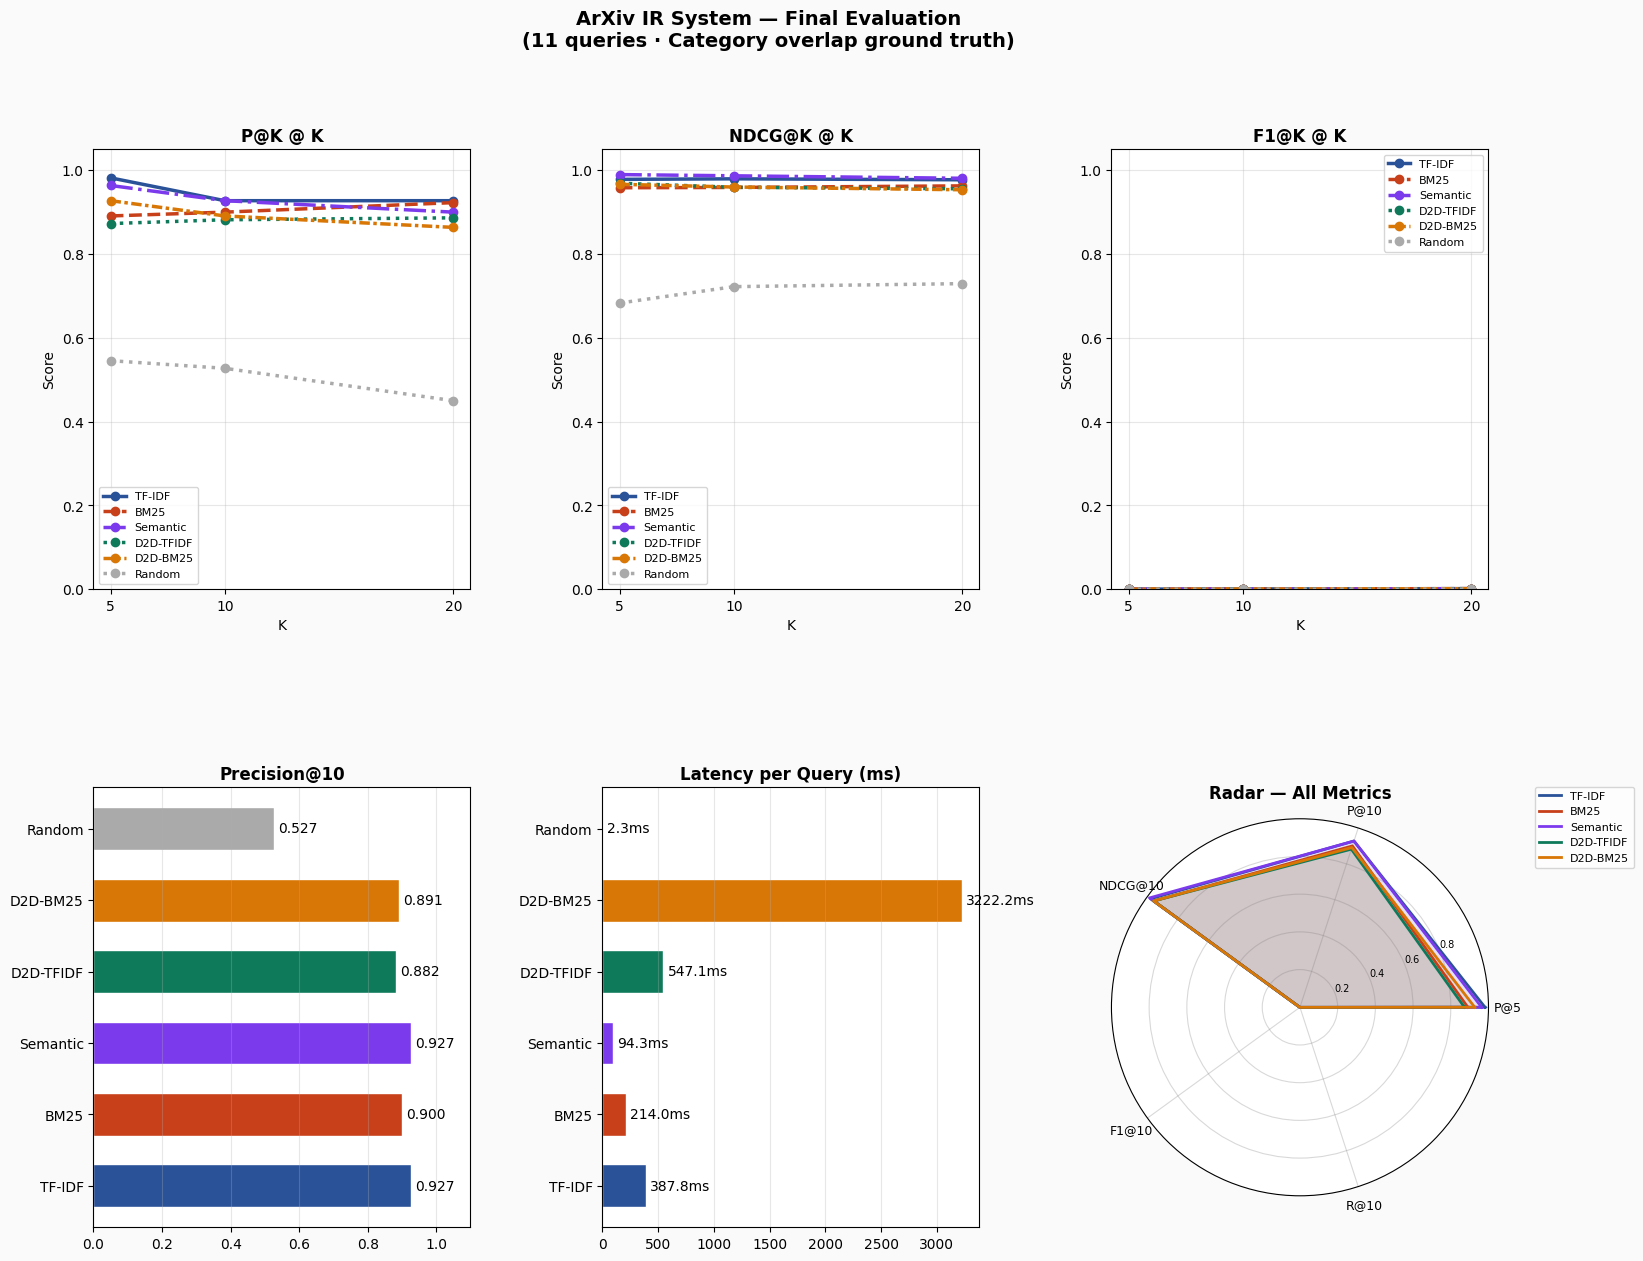

✅ Saved evaluation_final_chart.png!


In [21]:
def plot_comparison(eval_df: pd.DataFrame, summary: pd.DataFrame):
    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor('#fafafa')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    COLORS = {
        'TF-IDF':    '#2a5298',
        'BM25':      '#c8401a',
        'Semantic':  '#7c3aed',
        'D2D-TFIDF': '#0f7a5a',
        'D2D-BM25':  '#d97706',
        'Random':    '#aaaaaa',
    }
    LS = {
        'TF-IDF':'-', 'BM25':'--', 'Semantic':'-.',
        'D2D-TFIDF':':', 'D2D-BM25':(0,(3,1,1,1)), 'Random':':'
    }
    methods = list(COLORS.keys())
    k_vals  = [5, 10, 20]

    # ── Plot 1,2,3: Line chart P@K, NDCG@K, F1@K ─────────────
    for gi, metric in enumerate(['P@K','NDCG@K','F1@K']):
        ax = fig.add_subplot(gs[0, gi])
        for m in methods:
            vals = []
            for k in k_vals:
                try:    vals.append(summary.loc[(m,k), metric])
                except: vals.append(0)
            ax.plot(k_vals, vals,
                    label=m, color=COLORS[m],
                    linewidth=2.5, marker='o', markersize=6,
                    linestyle=LS[m])
        ax.set_title(f'{metric} @ K', fontweight='bold')
        ax.set_xlabel('K'); ax.set_ylabel('Score')
        ax.set_xticks(k_vals); ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Plot 4: Bar chart MAP (mean P@10) ─────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    p10 = [summary.loc[(m,10),'P@K'] if (m,10) in summary.index else 0
           for m in methods]
    bars = ax4.barh(methods, p10,
                    color=[COLORS[m] for m in methods],
                    edgecolor='white', height=0.6)
    ax4.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
    ax4.set_title('Precision@10', fontweight='bold')
    ax4.set_xlim(0, 1.1)
    ax4.grid(axis='x', alpha=0.3)

    # ── Plot 5: Latency comparison ────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    lat = [summary.loc[(m,10),'latency_ms'] if (m,10) in summary.index else 0
           for m in methods]
    bars2 = ax5.barh(methods, lat,
                     color=[COLORS[m] for m in methods],
                     edgecolor='white', height=0.6)
    ax5.bar_label(bars2, fmt='%.1fms', padding=3, fontsize=10)
    ax5.set_title('Latency per Query (ms)', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

    # ── Plot 6: Radar chart ───────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2], polar=True)
    radar_m = ['P@5','P@10','NDCG@10','F1@10','R@10']
    N       = len(radar_m)
    angles  = [n/N*2*np.pi for n in range(N)] + [0]
    ax6.set_xticks(angles[:-1])
    ax6.set_xticklabels(
        ['P@5','P@10','NDCG@10','F1@10','R@10'], size=9
    )
    ax6.set_ylim(0,1)
    ax6.set_yticks([0.2,0.4,0.6,0.8])
    ax6.set_yticklabels(['0.2','0.4','0.6','0.8'], size=7)
    ax6.grid(color='grey', alpha=0.3)

    for m in [x for x in methods if x != 'Random']:
        vals = []
        for col in ['P@K','P@K','NDCG@K','F1@K','R@K']:
            k_ = 5 if col == 'P@K' and vals == [] else 10
            try:    vals.append(summary.loc[(m,k_), col])
            except: vals.append(0)
        vals += vals[:1]
        ax6.plot(angles, vals, color=COLORS[m], linewidth=2, label=m)
        ax6.fill(angles, vals, color=COLORS[m], alpha=0.08)
    ax6.set_title('Radar — All Metrics', fontweight='bold', pad=15)
    ax6.legend(loc='upper right', bbox_to_anchor=(1.4,1.1), fontsize=8)

    plt.suptitle('ArXiv IR System — Final Evaluation\n'
                 f'({len(TEST_QUERIES)} queries · Category overlap ground truth)',
                 fontsize=14, fontweight='bold')
    plt.savefig('/kaggle/working/evaluation_final_chart.png',
                dpi=150, bbox_inches='tight', facecolor='#fafafa')
    plt.show()
    print("✅ Saved evaluation_final_chart.png!")

plot_comparison(eval_df, summary)

In [22]:
def per_query_analysis(eval_df: pd.DataFrame, k: int = 10):
    """Xem từng query method nào thắng"""
    pivot = eval_df[eval_df['k'] == k].pivot_table(
        index='query', columns='method', values='NDCG@K'
    ).round(3)

    # Highlight method tốt nhất mỗi query
    print(f"\n{'='*80}")
    print(f"  NDCG@{k} theo từng query — method tốt nhất được đánh dấu ★")
    print('='*80)
    for query, row in pivot.iterrows():
        best_m = row.drop('Random').idxmax()
        best_v = row[best_m]
        print(f"\n  Query: '{query}'")
        for m, v in row.items():
            star = ' ★' if m == best_m else '  '
            bar  = '█' * int(v * 20)
            print(f"    {m:<15} {v:.3f}  {bar}{star}")

    # Đếm method thắng nhiều nhất
    methods_no_rand = [m for m in pivot.columns if m != 'Random']
    wins = {m: 0 for m in methods_no_rand}
    for _, row in pivot.iterrows():
        best = row[methods_no_rand].idxmax()
        wins[best] += 1

    print(f"\n{'='*50}")
    print(f"  Số query thắng (NDCG@{k}):")
    for m, w in sorted(wins.items(), key=lambda x: -x[1]):
        bar = '█' * w
        print(f"    {m:<15}: {w:>2} queries  {bar}")

    return pivot

pivot = per_query_analysis(eval_df, k=10)


  NDCG@10 theo từng query — method tốt nhất được đánh dấu ★

  Query: 'contrastive learning self supervised rep'
    BM25            0.984  ███████████████████  
    D2D-BM25        1.000  ████████████████████ ★
    D2D-TFIDF       0.994  ███████████████████  
    Random          0.859  █████████████████  
    Semantic        1.000  ████████████████████  
    TF-IDF          0.994  ███████████████████  

  Query: 'dense retrieval passage ranking'
    BM25            1.000  ████████████████████ ★
    D2D-BM25        1.000  ████████████████████  
    D2D-TFIDF       1.000  ████████████████████  
    Random          1.000  ████████████████████  
    Semantic        1.000  ████████████████████  
    TF-IDF          1.000  ████████████████████  

  Query: 'few shot learning meta learning generali'
    BM25            0.920  ██████████████████  
    D2D-BM25        0.984  ███████████████████  
    D2D-TFIDF       1.000  ████████████████████ ★
    Random          0.534  ██████████  
    Sema

In [23]:
def per_query_analysis(eval_df: pd.DataFrame, k: int = 10):
    """Xem từng query method nào thắng"""
    pivot = eval_df[eval_df['k'] == k].pivot_table(
        index='query', columns='method', values='NDCG@K'
    ).round(3)

    # Highlight method tốt nhất mỗi query
    print(f"\n{'='*80}")
    print(f"  NDCG@{k} theo từng query — method tốt nhất được đánh dấu ★")
    print('='*80)
    for query, row in pivot.iterrows():
        best_m = row.drop('Random').idxmax()
        best_v = row[best_m]
        print(f"\n  Query: '{query}'")
        for m, v in row.items():
            star = ' ★' if m == best_m else '  '
            bar  = '█' * int(v * 20)
            print(f"    {m:<15} {v:.3f}  {bar}{star}")

    # Đếm method thắng nhiều nhất
    methods_no_rand = [m for m in pivot.columns if m != 'Random']
    wins = {m: 0 for m in methods_no_rand}
    for _, row in pivot.iterrows():
        best = row[methods_no_rand].idxmax()
        wins[best] += 1

    print(f"\n{'='*50}")
    print(f"  Số query thắng (NDCG@{k}):")
    for m, w in sorted(wins.items(), key=lambda x: -x[1]):
        bar = '█' * w
        print(f"    {m:<15}: {w:>2} queries  {bar}")

    return pivot

pivot = per_query_analysis(eval_df, k=10)


  NDCG@10 theo từng query — method tốt nhất được đánh dấu ★

  Query: 'contrastive learning self supervised rep'
    BM25            0.984  ███████████████████  
    D2D-BM25        1.000  ████████████████████ ★
    D2D-TFIDF       0.994  ███████████████████  
    Random          0.859  █████████████████  
    Semantic        1.000  ████████████████████  
    TF-IDF          0.994  ███████████████████  

  Query: 'dense retrieval passage ranking'
    BM25            1.000  ████████████████████ ★
    D2D-BM25        1.000  ████████████████████  
    D2D-TFIDF       1.000  ████████████████████  
    Random          1.000  ████████████████████  
    Semantic        1.000  ████████████████████  
    TF-IDF          1.000  ████████████████████  

  Query: 'few shot learning meta learning generali'
    BM25            0.920  ██████████████████  
    D2D-BM25        0.984  ███████████████████  
    D2D-TFIDF       1.000  ████████████████████ ★
    Random          0.534  ██████████  
    Sema

In [24]:
os.makedirs('/kaggle/working/eval_outputs', exist_ok=True)

eval_df.to_csv('/kaggle/working/eval_outputs/evaluation_final.csv',   index=False)
summary.to_csv('/kaggle/working/eval_outputs/summary_final.csv')
pivot.to_csv(  '/kaggle/working/eval_outputs/per_query_ndcg.csv')

print("✅ Tất cả files đã lưu:")
for f in sorted(os.listdir('/kaggle/working/eval_outputs')):
    size = os.path.getsize(f'/kaggle/working/eval_outputs/{f}')/1024
    print(f"  {f:<40} {size:.1f} KB")
print("\nCharts:")
for f in ['evaluation_final_chart.png','pr_curve_final.png']:
    path = f'/kaggle/working/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)/1024
        print(f"  {f:<40} {size:.0f} KB")

✅ Tất cả files đã lưu:
  evaluation_final.csv                     15.4 KB
  per_query_ndcg.csv                       0.8 KB
  summary_final.csv                        0.9 KB

Charts:
  evaluation_final_chart.png               293 KB
